Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda

Scanning dataset segments...

Segment: 1s_segment_raw
  Class: Single -> 1088 images
  Class: Double -> 1028 images
  Class: Empty -> 616 images
Segment: 1s_segment_trans
  Class: Single -> 1088 images
  Class: Empty -> 616 images
  Class: Double -> 1028 images
Segment: 2s_segment_raw
  Class: Double -> 514 images
  Class: Empty -> 308 images
  Class: Single -> 544 images
Segment: 2s_segment_trans
  Class: Single -> 544 images
  Class: Double -> 514 images
  Class: Empty -> 308 images
Segment: 4s_segment_raw
  Class: Single -> 272 images
  Class: Empty -> 154 images
  Class: Double -> 257 images
Segment: 4s_segment_trans
  Class: Single -> 272 images
  Class: Double -> 257 images
  Class: Empty -> 154 images

Total valid segments found: 6

Using data directory: /content/drive/MyDrive/100 mV/1s_segment_raw/train_val_photos
Training images  

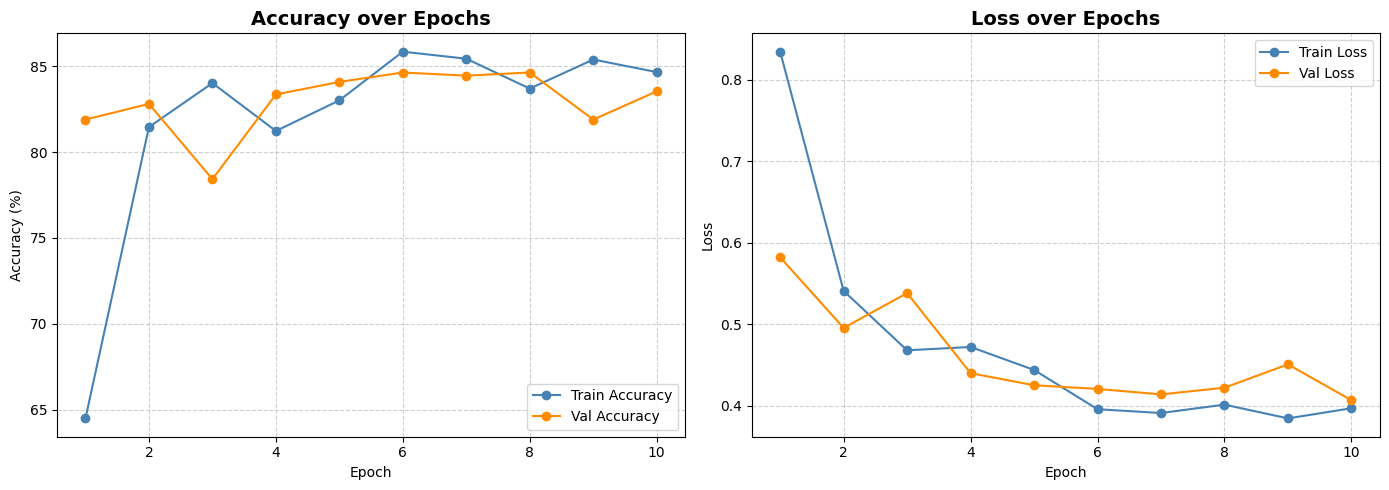

Accuracy & loss curves saved to resnet50_accuracy_loss_curves.png

Classification Report:
              precision    recall  f1-score   support

      Double     0.9290    0.8293    0.8763       205
       Empty     0.7724    0.7983    0.7851       119
      Single     0.8216    0.8879    0.8534       223

    accuracy                         0.8464       547
   macro avg     0.8410    0.8385    0.8383       547
weighted avg     0.8511    0.8464    0.8471       547

Classification report saved to classification_report.txt


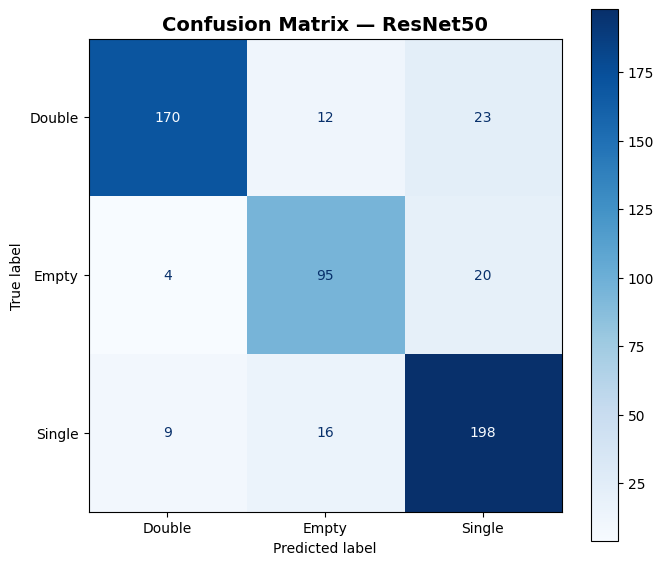

Confusion matrix saved to resnet50_confusion_matrix.png


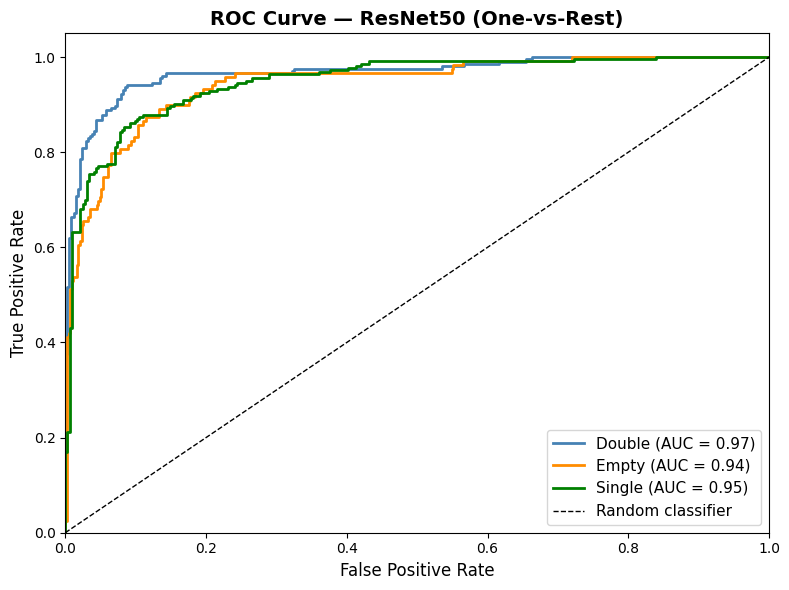

ROC curve saved to resnet50_roc_curve.png


In [8]:
from google.colab import drive
drive.mount('/content/drive')
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

# ─────────────────────────────────────────────
# 1. Configuration
# ─────────────────────────────────────────────
DATASET_BASE  = '/content/drive/MyDrive/100 mV'
NUM_CLASSES   = 3          # Single, Double, Empty
BATCH_SIZE    = 32
NUM_EPOCHS    = 10
LEARNING_RATE = 0.001
VAL_SPLIT     = 0.2        # 20% held out for validation

SEGMENTS = [
    '1s_segment_raw',
    '1s_segment_trans',
    '2s_segment_raw',
    '2s_segment_trans',
    '4s_segment_raw',
    '4s_segment_trans',
]

# ─────────────────────────────────────────────
# 2. Device
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ─────────────────────────────────────────────
# 3. Scan dataset structure
# ─────────────────────────────────────────────
print("\nScanning dataset segments...\n")
valid_paths = []

for seg in SEGMENTS:
    seg_path = os.path.join(DATASET_BASE, seg, 'train_val_photos')
    print(f"Segment: {seg}")
    if os.path.exists(seg_path):
        class_folders = [
            d for d in os.listdir(seg_path)
            if os.path.isdir(os.path.join(seg_path, d))
        ]
        if not class_folders:
            print(f"  No class subfolders found in {seg_path}")
            continue
        valid_paths.append(seg_path)
        for cls in class_folders:
            cls_path = os.path.join(seg_path, cls)
            num_imgs = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            print(f"  Class: {cls} -> {num_imgs} images")
    else:
        print(f"  Path does NOT exist: {seg_path}")

print(f"\nTotal valid segments found: {len(valid_paths)}")

if not valid_paths:
    raise RuntimeError("No valid dataset paths found. Check DATASET_BASE.")

# ─────────────────────────────────────────────
# 4. Transforms & DataLoaders
# ─────────────────────────────────────────────
data_dir = valid_paths[0]          # default: first valid segment
print(f"\nUsing data directory: {data_dir}")

transform = transforms.Compose([
    transforms.Resize((224, 224)),                       # Smaller size for faster training
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],    # ImageNet statistics
                         std=[0.229, 0.224, 0.225]),
])

full_dataset = ImageFolder(root=data_dir, transform=transform)

train_size = int((1 - VAL_SPLIT) * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

pin = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=pin)

print(f"Training images  : {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Classes          : {full_dataset.classes}")

# ─────────────────────────────────────────────
# 5. Model — ResNet50 (pretrained, fine-tuned)
# ─────────────────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final FC layer — ResNet50 uses model.fc just like GoogLeNet
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
# model.fc is newly created so requires_grad=True by default

model = model.to(device)
print(f"\nModel ready. Output classes: {NUM_CLASSES}")

# ─────────────────────────────────────────────
# 6. Loss & Optimizer
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)  # only train the head

# ─────────────────────────────────────────────
# 7. Training & Evaluation Functions
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)   # ResNet50 always returns a plain tensor
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    return running_loss / total, 100.0 * correct / total


def evaluate_full(model, loader, device, num_classes):
    """Returns all true labels, predicted labels, and softmax probabilities."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(labels.numpy())

    return (np.concatenate(all_labels),
            np.concatenate(all_preds),
            np.concatenate(all_probs, axis=0))

# ─────────────────────────────────────────────
# 8. Training Loop
# ─────────────────────────────────────────────
print("\nStarting training...\n")
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch:>2}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet50.pth')
        print(f"  → Best model saved (Val Acc: {best_val_acc:.2f}%)")

print(f"\nTraining complete. Best validation accuracy: {best_val_acc:.2f}%")

# ─────────────────────────────────────────────
# 9. Accuracy & Loss Graphs
# ─────────────────────────────────────────────
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_acc'], 'o-', color='steelblue',  label='Train Accuracy')
ax1.plot(epochs_range, history['val_acc'],   'o-', color='darkorange', label='Val Accuracy')
ax1.set_title('Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(epochs_range, history['train_loss'], 'o-', color='steelblue',  label='Train Loss')
ax2.plot(epochs_range, history['val_loss'],   'o-', color='darkorange', label='Val Loss')
ax2.set_title('Loss over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('resnet50_accuracy_loss_curves.png', dpi=150)
plt.show()
print("Accuracy & loss curves saved to resnet50_accuracy_loss_curves.png")

# ─────────────────────────────────────────────
# 10. Load best model & collect predictions
# ─────────────────────────────────────────────
model.load_state_dict(torch.load('best_resnet50.pth', map_location=device))
class_names = full_dataset.classes

true_labels, pred_labels, pred_probs = evaluate_full(model, val_loader, device, NUM_CLASSES)
# ─────────────────────────────────────────────
# 10b. Precision, Recall & F1 Score
# ─────────────────────────────────────────────
report = classification_report(true_labels, pred_labels, target_names=class_names, digits=4)
print("\nClassification Report:")
print(report)

# Optional: save to a text file
with open("classification_report.txt", "w") as f:
    f.write(report)
print("Classification report saved to classification_report.txt")

# ─────────────────────────────────────────────
# 11. Confusion Matrix
# ─────────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — ResNet50', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved to resnet50_confusion_matrix.png")

# ─────────────────────────────────────────────
# 12. ROC Curve (One-vs-Rest, one curve per class)
# ─────────────────────────────────────────────
true_binarized = label_binarize(true_labels, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'green']

for i, (cls_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(true_binarized[:, i], pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls_name} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — ResNet50 (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('resnet50_roc_curve.png', dpi=150)
plt.show()
print("ROC curve saved to resnet50_roc_curve.png")

In [2]:
!pip install -q "pandas==2.2.2" "scikit-learn" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 33.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.5 which is incompatible.
